In [85]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf

In [86]:
import tensorflow.keras.utils as tku

In [87]:
from sklearn.datasets import fetch_openml
mnist = fetch_openml('mnist_784')

In [88]:
print(mnist)

{'data':        pixel1  pixel2  pixel3  pixel4  pixel5  pixel6  pixel7  pixel8  pixel9  \
0           0       0       0       0       0       0       0       0       0   
1           0       0       0       0       0       0       0       0       0   
2           0       0       0       0       0       0       0       0       0   
3           0       0       0       0       0       0       0       0       0   
4           0       0       0       0       0       0       0       0       0   
...       ...     ...     ...     ...     ...     ...     ...     ...     ...   
69995       0       0       0       0       0       0       0       0       0   
69996       0       0       0       0       0       0       0       0       0   
69997       0       0       0       0       0       0       0       0       0   
69998       0       0       0       0       0       0       0       0       0   
69999       0       0       0       0       0       0       0       0       0   

       pixel10  ..

In [89]:
print(mnist['data'].iloc[0])

pixel1      0
pixel2      0
pixel3      0
pixel4      0
pixel5      0
           ..
pixel780    0
pixel781    0
pixel782    0
pixel783    0
pixel784    0
Name: 0, Length: 784, dtype: int64


In [90]:
X, y = mnist['data'], mnist['target']

In [91]:
print(X)

       pixel1  pixel2  pixel3  pixel4  pixel5  pixel6  pixel7  pixel8  pixel9  \
0           0       0       0       0       0       0       0       0       0   
1           0       0       0       0       0       0       0       0       0   
2           0       0       0       0       0       0       0       0       0   
3           0       0       0       0       0       0       0       0       0   
4           0       0       0       0       0       0       0       0       0   
...       ...     ...     ...     ...     ...     ...     ...     ...     ...   
69995       0       0       0       0       0       0       0       0       0   
69996       0       0       0       0       0       0       0       0       0   
69997       0       0       0       0       0       0       0       0       0   
69998       0       0       0       0       0       0       0       0       0   
69999       0       0       0       0       0       0       0       0       0   

       pixel10  ...  pixel7

In [92]:
print(y)

0        5
1        0
2        4
3        1
4        9
        ..
69995    2
69996    3
69997    4
69998    5
69999    6
Name: class, Length: 70000, dtype: category
Categories (10, object): ['0', '1', '2', '3', ..., '6', '7', '8', '9']


In [93]:
X.shape

(70000, 784)

In [94]:
y.shape

(70000,)

In [95]:
demo_digit = X.iloc[1871].values
demo_digit = demo_digit.reshape(28, 28)

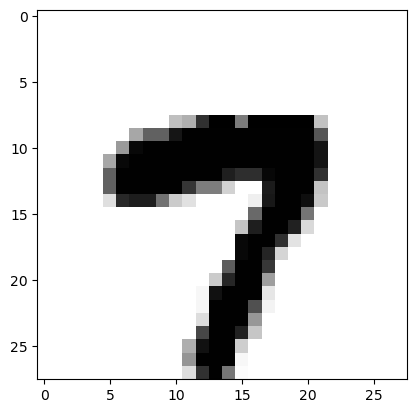

In [96]:
plt.imshow(demo_digit, cmap = matplotlib.cm.binary, interpolation='nearest')

In [97]:
print(y[1871])

7


In [98]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20, random_state = 0)

In [99]:
cnn = tf.keras.models.Sequential()

In [100]:
cnn.add(tf.keras.layers.Dense(64, activation = 'relu', input_dim = 784))
cnn.add(tf.keras.layers.Dense(64, activation = 'relu'))
cnn.add(tf.keras.layers.Dense(10, activation = 'softmax'))

C:\Users\Rahul\Downloads\Anaconda\Projects\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [101]:
cnn.compile(optimizer = 'adam', loss = 'categorical_crossentropy', metrics = ['accuracy'])

In [102]:
cnn.fit(X_train, tku.to_categorical(y_train), epochs = 5, batch_size = 32)

Epoch 1/5
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.7384 - loss: 4.4215
Epoch 2/5
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8947 - loss: 0.4368
Epoch 3/5
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9190 - loss: 0.3188
Epoch 4/5
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9308 - loss: 0.2695
Epoch 5/5
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9414 - loss: 0.2296


In [103]:
cnn.evaluate(X_test, tku.to_categorical(y_test))

438/438 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9383 - loss: 0.2413


[0.26308637857437134, 0.9349285960197449]

In [104]:
test_image = X.iloc[1871]

In [105]:
test_image = np.expand_dims(test_image, axis = 0)
result = cnn.predict(test_image)
print(result)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step
[[4.69607020e-09 2.49114812e-10 1.38595533e-06 4.63164262e-08
  4.01058131e-10 1.44979094e-06 2.05167745e-14 9.99979496e-01
  1.03943325e-08 1.76474350e-05]]
